In [43]:
from PIL import Image
import numpy as np
import pandas as pd
from calibration import lifetime_to_temperature_201112
import matplotlib.pyplot as plt
import glob
from matplotlib.backends.backend_pdf import PdfPages

In [44]:
before = glob.glob('./200904_sigma_lin22.6/cyto/*before*/*ch01.tif')
before.sort()
during = glob.glob('./200904_sigma_lin22.6/cyto/*during/*ch01.tif')
during.sort()
intensity_before_path = glob.glob('./200904_sigma_lin22.6/cyto/*before*/*ch00.tif')
intensity_before_path.sort()
intensity_during_path = glob.glob('./200904_sigma_lin22.6/cyto/*during*/*ch00.tif')
intensity_during_path.sort()

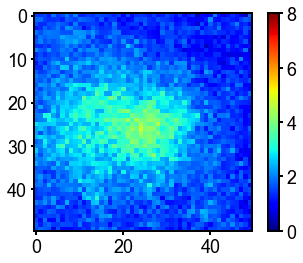

In [45]:
#中心を探して平均化
increase_tmp_ave_cyto = np.zeros((50, 50))
data_set_Increase_tmp_cyto = pd.DataFrame()
data_set_before_tmp_cyto = pd.DataFrame()

for i in range(len(before)):
    before_lifetime = np.array(Image.open(before[i]))
    during_lifetime = np.array(Image.open(during[i]))    

    before_lifetime = (before_lifetime)/1000    
    before_tmp = lifetime_to_temperature_201112(before_lifetime)                          
    during_lifetime = (during_lifetime)/1000
    during_tmp = lifetime_to_temperature_201112(during_lifetime)

    increase_tmp = during_tmp - before_tmp
    
    #中心を探す
    before_intensity = np.array(Image.open(intensity_before_path[i]))
    during_intensity = np.array(Image.open(intensity_during_path[i]))
    ratio = during_intensity/before_intensity
    ratio_bin4 = ratio.reshape(16, 4, 16, 4).mean(-1).mean(1)
    index = np.unravel_index(np.argmax(ratio_bin4), ratio_bin4.shape)
    
    x_index = index[0]*4
    y_index = index[1]*4
    increase_tmp = increase_tmp[x_index-24 : x_index+26, y_index-24 : y_index+26]
    before_tmp = before_tmp[x_index-24 : x_index+26, y_index-24 : y_index+26]
    increase_tmp_ave_cyto += increase_tmp
    data_set_Increase_tmp_cyto = pd.concat([data_set_Increase_tmp_cyto, pd.DataFrame(increase_tmp[:, 25])], axis = 1)
    data_set_before_tmp_cyto = pd.concat([data_set_before_tmp_cyto, pd.DataFrame(before_tmp[:, 25])], axis = 1)
    
increase_tmp_ave_cyto = increase_tmp_ave_cyto/len(before)
plt.imshow(increase_tmp_ave_cyto, cmap = 'jet', vmin = 0, vmax = 8)
plt.tick_params(labelbottom="off",bottom="off") # x軸の削除
plt.tick_params(labelleft="off",left="off") # y軸の削除
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 18
plt.colorbar()
plt.show()

df = pd.DataFrame(increase_tmp_ave_cyto[:, 25])
df.to_csv('./cyto.csv')
data_set_Increase_tmp_cyto.to_csv('./data_set_cyto.csv')
data_set_before_tmp_cyto.to_csv('./data_set_before_cyto.csv')

In [46]:
before = glob.glob('./200904_sigma_lin22.6/nuc/*before*/*ch01.tif')
before.sort()
during = glob.glob('./200904_sigma_lin22.6/nuc/*during*/*ch01.tif')
during.sort()
intensity_during_path = glob.glob('./200904_sigma_lin22.6/nuc/*during*/*ch00.tif')
intensity_during_path.sort()
intensity_before_path = glob.glob('./200904_sigma_lin22.6/nuc/*before*/*ch00.tif')
intensity_before_path.sort()

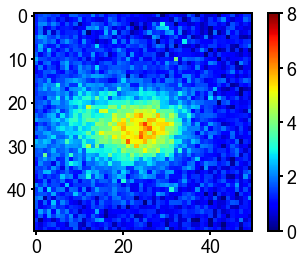

In [47]:
#中心を探して平均化
increase_tmp_ave_nuc = np.zeros((50, 50))
data_set_Increase_tmp_nuc = pd.DataFrame()
data_set_before_tmp_nuc = pd.DataFrame()

for i in range(len(before)):
    before_lifetime = np.array(Image.open(before[i]))
    during_lifetime = np.array(Image.open(during[i]))    

    before_lifetime = (before_lifetime)/1000    
    before_tmp = lifetime_to_temperature_201112(before_lifetime)
                               
    during_lifetime = (during_lifetime)/1000
    during_tmp = lifetime_to_temperature_201112(during_lifetime)

    increase_tmp = during_tmp - before_tmp
    #中心を探す
    before_intensity = np.array(Image.open(intensity_before_path[i]))
    during_intensity = np.array(Image.open(intensity_during_path[i]))
    ratio = during_intensity/before_intensity
    ratio_bin4 = ratio.reshape(16, 4, 16, 4).mean(-1).mean(1)
    index = np.unravel_index(np.argmax(ratio_bin4), ratio_bin4.shape)
    
    x_index = index[0]*4
    y_index = index[1]*4
    increase_tmp = increase_tmp[x_index-24 : x_index+26, y_index-24 : y_index+26]
    before_tmp = before_tmp[x_index-24 : x_index+26, y_index-24 : y_index+26]
    increase_tmp_ave_nuc += increase_tmp
    data_set_Increase_tmp_nuc = pd.concat([data_set_Increase_tmp_nuc, pd.DataFrame(increase_tmp[:, 25])], axis = 1)
    data_set_before_tmp_nuc = pd.concat([data_set_before_tmp_nuc, pd.DataFrame(before_tmp[:, 25])], axis = 1)
    
increase_tmp_ave_nuc = increase_tmp_ave_nuc/len(before)
plt.imshow(increase_tmp_ave_nuc, cmap = 'jet', vmin = 0, vmax = 8)
plt.tick_params(labelbottom="off",bottom="off") # x軸の削除
plt.tick_params(labelleft="off",left="off") # y軸の削除
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 18
plt.colorbar()
plt.show()

df = pd.DataFrame(increase_tmp_ave_nuc[:, 25])
df.to_csv('./nuc.csv')
data_set_Increase_tmp_nuc.to_csv('./data_set_nuc.csv')
data_set_before_tmp_nuc.to_csv('./data_set_before_nuc.csv')

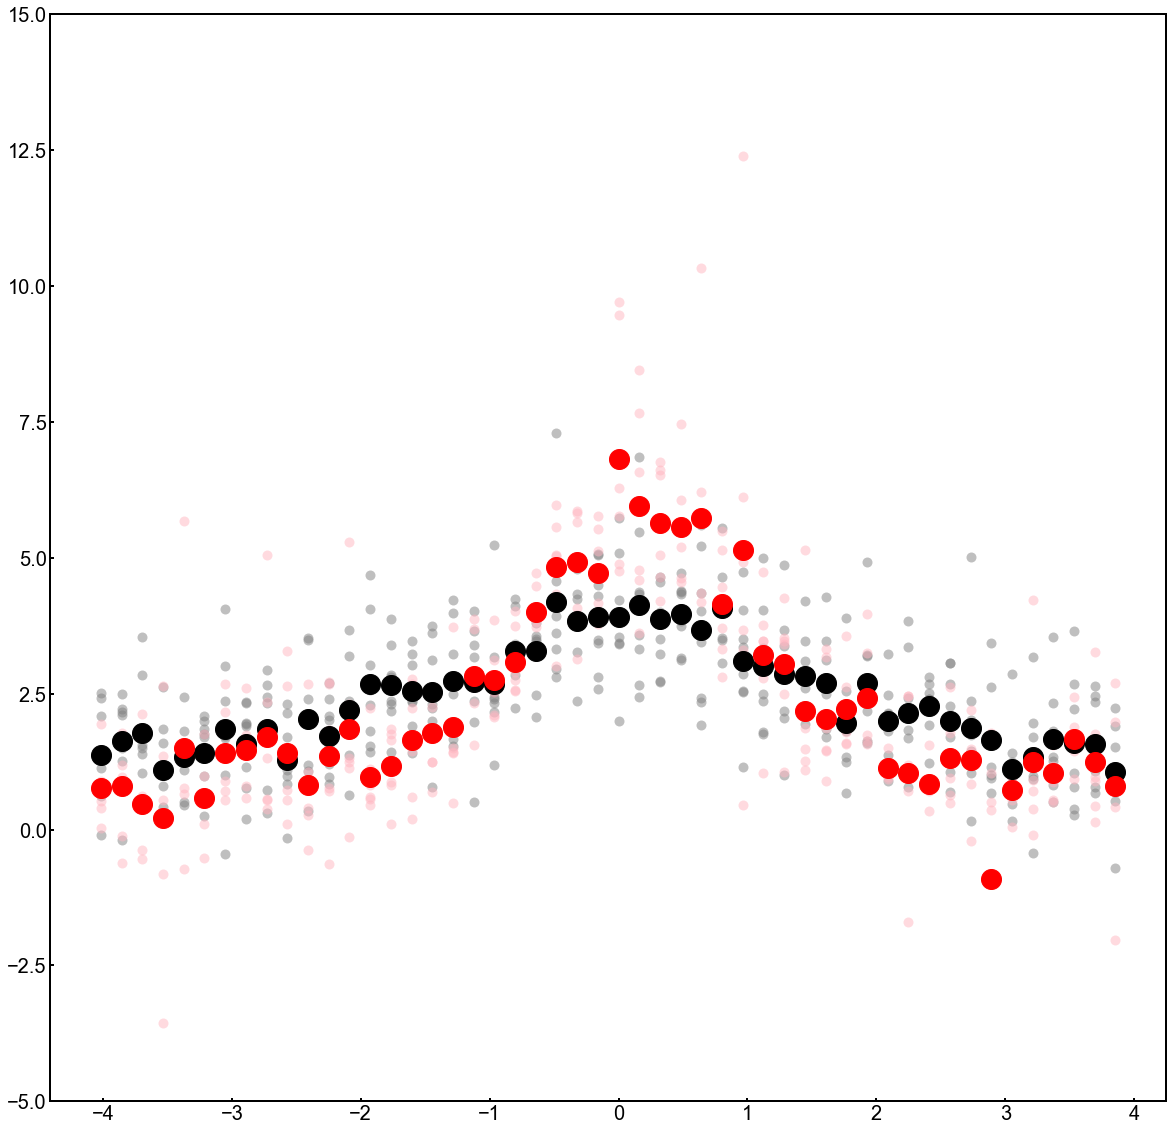

In [48]:
position = [(i-25)*0.160625 for i in range(50)]

#図の体裁調整
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 20)


plt.plot(position, data_set_Increase_tmp_cyto, markersize = 10, linewidth = 0, marker = 'o', color = 'grey', alpha = 0.5, markeredgewidth = 0)
plt.plot(position, data_set_Increase_tmp_nuc, markersize = 10, linewidth = 0, marker = 'o', color = 'lightpink', alpha = 0.5, markeredgewidth = 0)
plt.plot(position, increase_tmp_ave_cyto[:, 25], markersize = 20, linewidth = 0, marker = 'o', color = 'black')
plt.plot(position, increase_tmp_ave_nuc[:, 25], markersize = 20, linewidth = 0, marker = 'o', color = 'red')
plt.ylim(-5, 15)
plt.show()

#pdfのセーブ
pp = PdfPages('./FigS6.pdf')
pp.savefig(fig)
pp.close()

In [49]:
pd.DataFrame(position).to_csv('position.csv')